In [101]:
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns


In [102]:
df=pd.read_csv('/Users/rakumar2601/Desktop/ML_BASICS/Project1/titanic/train.csv')
print(df.columns)
df.head()
# df.shape
# df['Survived'].value_counts()
# df.nunique()
# sns.countplot(x='Survived',data=df)  


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='count'>

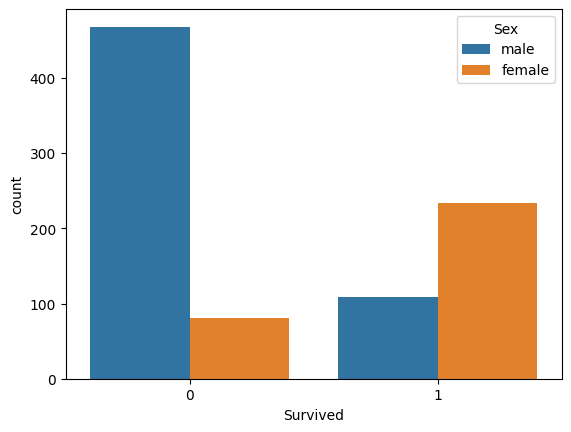

In [103]:
sns.countplot(x='Survived',hue='Sex',data=df)


In [105]:
df.isnull().sum() 

# as age has 177 null values we will fill it with mean value of age column
# but for the cabin as it is more than 77 percent its best to drop the column

df['Age']=df['Age'].fillna(df['Age'].mean(),inplace=True)
df.drop(columns='Cabin',inplace=True)
# df.drop(columns=['age'],inplace=True,errors='ignore')
df

/var/folders/w4/p5z5dkzn2jzb_y46x2y01r900000gp/T/ipykernel_69838/3163853496.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age']=df['Age'].fillna(df['Age'].mean(),inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [106]:
df.isnull().sum()
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [107]:
# these are only identifiers and they are not useful for our analysis so we will drop them
df.drop(columns=['Name','Ticket'],inplace=True,errors='ignore')
df.drop(columns='PassengerId',inplace=True,errors='ignore')
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [108]:
from scipy.stats import f_oneway
from sklearn.feature_selection import chi2
from scipy.stats import chi2_contingency




In [109]:

contigency_table1 = pd.crosstab(df['Survived'], df['Pclass'])
contigency_table2 = pd.crosstab(df['Survived'], df['Sex'])
chi2_contingency(contigency_table1)

Chi2ContingencyResult(statistic=np.float64(102.88898875696056), pvalue=np.float64(4.549251711298793e-23), dof=2, expected_freq=array([[133.09090909, 113.37373737, 302.53535354],
       [ 82.90909091,  70.62626263, 188.46464646]]))

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.9 KB


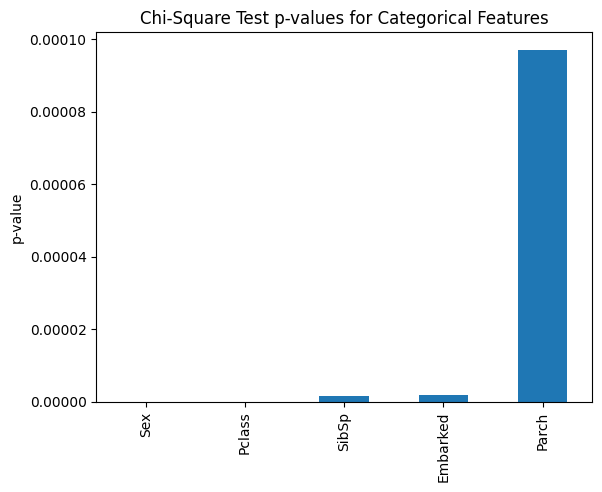

In [111]:
result=[]
cols=[]
for col in df.columns:
    if (df[col].dtype=='object' or df[col].nunique()<=10 ) and col!='Survived':
        contigency_table = pd.crosstab(df['Survived'], df[col])
        chi2, p, dof, expected = chi2_contingency(contigency_table)
        result.append(p)
        cols.append(col)

pd.Series(result, index=cols).sort_values().plot(kind='bar')
plt.ylabel('p-value')
plt.title('Chi-Square Test p-values for Categorical Features')
plt.show()


In [112]:
df.isnull().sum()
df.drop(columns=['Cabin'],inplace=True,errors='ignore')
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df.isnull().sum()


/var/folders/w4/p5z5dkzn2jzb_y46x2y01r900000gp/T/ipykernel_69838/639061239.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

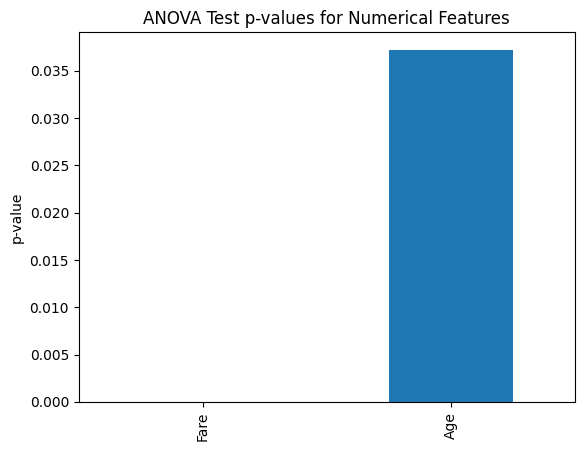

In [113]:
from scipy.stats import f_oneway

result = []
num_cols = []
for col in df.columns:
    if df[col].dtype != 'object' and df[col].nunique() > 10 and col != 'Survived':
        survived = df[df['Survived'] == 1][col]
        not_survived = df[df['Survived'] == 0][col]
        f_stat, p_value = f_oneway(survived, not_survived)
        result.append(p_value)
        num_cols.append(col)

pd.Series(result, index=num_cols).sort_values().plot(kind='bar')
plt.ylabel('p-value')
plt.title('ANOVA Test p-values for Numerical Features')
plt.show()


In [114]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [116]:
test_df = pd.read_csv('/Users/rakumar2601/Desktop/ML_BASICS/Project1/titanic/test.csv')
test_df.isnull().sum()
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].mean())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
test_df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], inplace=True, errors='ignore')


test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

test_df.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,34.5,0,0,7.8292,2
1,3,1,47.0,1,0,7.0000,0
2,2,0,62.0,0,0,9.6875,2
3,3,0,27.0,0,0,8.6625,0
4,3,1,22.0,1,1,12.2875,0


In [117]:
test_df = pd.get_dummies(test_df, columns=['Sex','Embarked'], drop_first=True)
test_df.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_1,Embarked_1,Embarked_2
0,3,34.5,0,0,7.8292,False,False,True
1,3,47.0,1,0,7.0000,True,False,False
2,2,62.0,0,0,9.6875,False,False,True
3,3,27.0,0,0,8.6625,False,False,False
4,3,22.0,1,1,12.2875,True,False,False


In [118]:
from sklearn.linear_model import LogisticRegression

X_train = df.drop(columns='Survived')
y_train = df['Survived']
X_test = test_df

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Embarked_1
- Embarked_2
- Sex_1
Feature names seen at fit time, yet now missing:
- Embarked
- Sex


In [120]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load original test to get PassengerId
test_raw = pd.read_csv('/Users/rakumar2601/Desktop/ML_BASICS/Project1/titanic/test.csv')

# Train model
X_train = df.drop(columns='Survived')
y_train = df['Survived']
X_test = test_df.reindex(columns=X_train.columns, fill_value=0)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Survived': y_pred
})
submission.to_csv('submission.csv', index=False)
print(submission.head())


   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


In [84]:
from sklearn.metrics import accuracy_score
train_pred = model.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, train_pred)}")


Training Accuracy: 0.8024691358024691


In [85]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

train = pd.read_csv('/Users/rakumar2601/Desktop/ML_BASICS/Project1/titanic/train.csv')
test = pd.read_csv('/Users/rakumar2601/Desktop/ML_BASICS/Project1/titanic/test.csv')

cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

X_train = train[cols].fillna(0)
y_train = train['Survived']
X_test = test[cols].fillna(0)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)


[0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 1
 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0
 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1
 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 0
 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0
 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0
 1 0 0 0 1 0 0 1 0 0 0]


In [86]:
from sklearn.metrics import accuracy_score
train_pred = model.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, train_pred)}")

Training Accuracy: 0.7048260381593715
